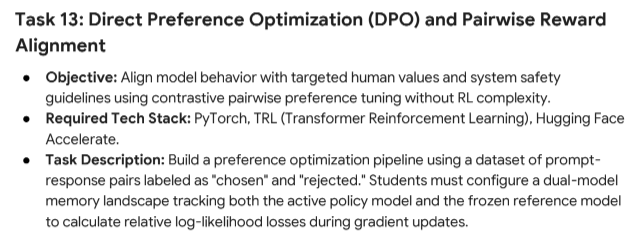

In [ ]:
!pip install torch transformers datasets

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

# 1. Load small language model

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# GPT-2 does not have a padding token
tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")


# 2. Preference dataset

data = [
    {
        "prompt": "What is a robot?",
        "chosen": "A robot is a machine that can sense, process information and perform actions.",
        "rejected": "A robot is just a computer screen."
    },

    {
        "prompt": "What is artificial intelligence?",
        "chosen": "Artificial intelligence enables machines to perform tasks that normally require human intelligence.",
        "rejected": "Artificial intelligence is only used for games."
    },

    {
        "prompt": "What is machine learning?",
        "chosen": "Machine learning allows computers to learn patterns from data.",
        "rejected": "Machine learning means manually programming every answer."
    }
]


# 3. Calculate response log probability

def get_log_probability(text):

    inputs = tokenizer(
        text,
        return_tensors="pt"
    )

    with torch.no_grad():

        output = model(
            **inputs
        )

    logits = output.logits

    labels = inputs["input_ids"]

    # Shift values for next-token prediction
    logits = logits[:, :-1, :]
    labels = labels[:, 1:]

    log_probs = F.log_softmax(
        logits,
        dim=-1
    )

    token_log_probs = log_probs.gather(
        2,
        labels.unsqueeze(-1)
    ).squeeze(-1)

    return token_log_probs.sum().item()


# 4. DPO comparison

chosen_scores = []
rejected_scores = []

for item in data:

    chosen_text = (
        item["prompt"] +
        " " +
        item["chosen"]
    )

    rejected_text = (
        item["prompt"] +
        " " +
        item["rejected"]
    )

    chosen_score = get_log_probability(
        chosen_text
    )

    rejected_score = get_log_probability(
        rejected_text
    )

    chosen_scores.append(
        chosen_score
    )

    rejected_scores.append(
        rejected_score
    )

    print("\nPrompt:", item["prompt"])

    print(
        "Chosen score:",
        round(chosen_score, 3)
    )

    print(
        "Rejected score:",
        round(rejected_score, 3)
    )


# 5. Calculate preference accuracy

correct = 0

for c, r in zip(
    chosen_scores,
    rejected_scores
):

    if c > r:
        correct += 1

accuracy = (
    correct /
    len(data)
) * 100

print(
    "\nPreference Accuracy:",
    round(accuracy, 2),
    "%"
)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model loaded!

Prompt: What is a robot?
Chosen score: -58.588
Rejected score: -40.514

Prompt: What is artificial intelligence?
Chosen score: -54.19
Rejected score: -43.742

Prompt: What is machine learning?
Chosen score: -51.365
Rejected score: -64.452

Preference Accuracy: 33.33 %


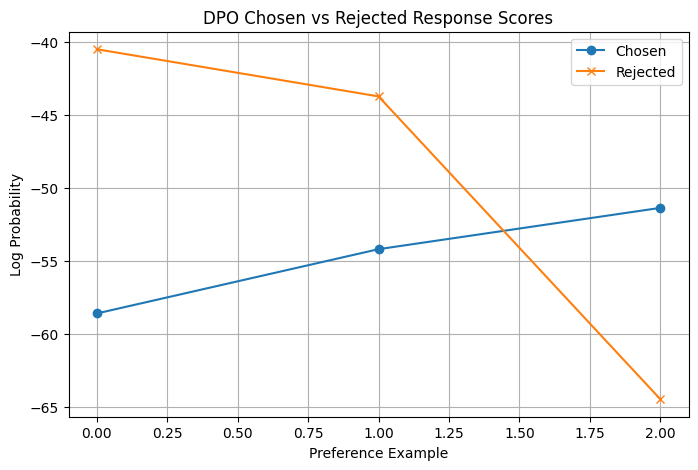

In [ ]:
import matplotlib.pyplot as plt

x = range(len(data))

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    chosen_scores,
    marker="o",
    label="Chosen"
)

plt.plot(
    x,
    rejected_scores,
    marker="x",
    label="Rejected"
)

plt.xlabel("Preference Example")
plt.ylabel("Log Probability")

plt.title(
    "DPO Chosen vs Rejected Response Scores"
)

plt.legend()
plt.grid()

plt.show()